# [실습] 군집화 · 차원축소

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

# 🧭 [실습] 군집화와 차원축소 — 정답 없이 구조를 찾는다

## — 구매 정답을 군집 입력에서 제외하고 방문 세션 패턴을 탐색합니다

순서 1~5에서는 `Revenue`를 타깃으로 예측·평가·피처·Pipeline을 다뤘습니다. 오늘은 이 열을 **군집 입력에서 제외한 채** 방문 세션의 행동 패턴을 탐색하고, 그 결과를 디지털 마케팅·사이트 개선 가설로 번역합니다.

> 🤖 **오늘의 AI 활용 규칙 — 협업 단계**  
> 코드 작성은 AI와 협업할 수 있습니다. 세그먼트 이름과 액션 가설은 프로파일 수치와 한계를 근거로 학습자가 결정합니다. AI 사용 내역에는 요청·수정·검증을 기록합니다.

## 📋 오늘의 과제

디지털 분석팀이 다음을 묻습니다.

> 🧑‍💼 "방문 세션을 행동 패턴별로 나눠 사이트 경험과 캠페인 가설을 다르게 설계할 수 있을까요? 그 패턴을 구매 예측 모델에도 활용할 수 있을까요?"

| 문제 | 내용 | 확인하는 힘 |
| --- | --- | --- |
| 1 | Elbow와 Silhouette으로 `k` 후보를 좁힘 | 지표와 운영 제약의 조율 |
| 2 | 군집화·프로파일·PCA 2D | 투영 그림과 원본 프로파일 구분 |
| 3 | 세그먼트 카드 — 패턴·근거·액션 가설 | 번호를 업무 언어로 번역 |
| 4 | 군집 중심거리 피처를 예측에 재투입 | 같은 표현으로 공정하게 비교 |
| 5 | 모델 카드 v6 완성 | 정답 없는 결과와 한계 보고 |

> ⚠️ **오늘의 규율**  
> 군집 입력에는 `Revenue`를 넣지 않습니다. 군집화 뒤에 그룹별 구매율을 외부 지표로 비교할 수 있지만, 같은 데이터에서 확인한 연관성을 액션의 인과 효과로 해석하지 않습니다. `PageValues`도 거래 완료와 관련해 계산되는 지표이므로 실제 운영에서는 값이 확정되는 시점을 먼저 감사합니다.

# ⚙️ 데이터 준비

순서 1~5에서 사용한 UCI **Online Shoppers Purchasing Intention** 데이터를 다시 사용합니다. 이번 목적은 고객 분류가 아니라 **방문 세션 패턴의 회고적 탐색**입니다.

| 항목 | 내용 |
| --- | --- |
| 관측 단위 | 온라인 쇼핑 방문 세션 1건 |
| 크기 | 12,330행 · 입력 피처 17개 + 타깃 `Revenue` 1개 |
| 클래스 분포 | 구매 1,908건(15.5%) · 비구매 10,422건(84.5%) |
| 결측치 | 없음 |
| 이번 군집 입력 | 행동 수치 피처 7개 · `Revenue` 제외 |
| 출처·이용 조건 | UCI DOI `10.24432/C5F88Q` · CC BY 4.0 |

이 데이터는 세션 단위이며 고객 식별자·반복 방문 이력이 없습니다. 따라서 결과는 **고객 페르소나가 아니라 세션 행동 유형**으로 해석합니다. 실제 개인화 캠페인에는 고객 단위 집계와 동의·식별 기준이 추가로 필요합니다.

### 군집 피처 선택

- 페이지 수: `Administrative`, `Informational`, `ProductRelated`
- 체류: `ProductRelated_Duration`
- 이탈 성향: `BounceRates`, `ExitRates`
- 거래 관련: `PageValues`

`Month`·`Region` 같은 범주형 맥락은 단순 유클리드 거리에 바로 넣지 않았습니다. 행동과 무관해서가 아니라, 적절한 인코딩·거리·가중치 설계가 별도로 필요하기 때문입니다. 일부 체류 피처를 제외한 것도 학습 예제를 단순화한 선택이며 유일한 정답이 아닙니다.

> ⚠️ **`PageValues` 시점 감사**  
> UCI 설명상 `PageValues`는 전자상거래 거래 완료와 관련해 계산됩니다. 이 노트북은 완료된 세션을 회고적으로 탐색하므로 포함하지만, 세션 중 실시간 개입이나 구매 예측에 쓰려면 요청 시점에 값이 확정되어 있는지 확인합니다. 이 피처 때문에 군집별 구매율 차이가 크게 나타날 수 있습니다.

선택한 수치 피처는 단위가 크게 다르므로, 이번 목적에서는 `StandardScaler`로 같은 가중치를 부여합니다.

▶️ **코드 실행하기 · 코드 셀 1 [C1]**

In [1]:
# ─────────────────────────────────────────────
# [C1] ⚙️ 데이터 준비
# 최초 1회 다운로드 → data/ 폴더에 저장 (이후 오프라인)
# ─────────────────────────────────────────────
import urllib.request, zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

def fetch_uci(url, zip_name, member):
    """UCI 정적 저장소의 zip을 내려받아 data/에 풀고, CSV 경로를 돌려줍니다."""
    csv_path = DATA_DIR / member
    if not csv_path.exists():
        zip_path = DATA_DIR / zip_name
        if not zip_path.exists():
            print(f"내려받는 중… {zip_name}")
            urllib.request.urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path) as z:
            z.extract(member, DATA_DIR)
    return csv_path

shoppers = pd.read_csv(fetch_uci(
    "https://archive.ics.uci.edu/static/public/468/online+shoppers+purchasing+intention+dataset.zip",
    "online_shoppers.zip", "online_shoppers_intention.csv"))

NUM_COLS = ["Administrative", "Administrative_Duration", "Informational",
            "Informational_Duration", "ProductRelated", "ProductRelated_Duration",
            "BounceRates", "ExitRates", "PageValues", "SpecialDay"]
CAT_COLS = ["Month", "OperatingSystems", "Browser", "Region",
            "TrafficType", "VisitorType", "Weekend"]

# 군집화에 쓸 '행동' 피처 7개 — Revenue는 절대 포함하지 않습니다
CLUSTER_COLS = ["Administrative", "Informational", "ProductRelated",
                "ProductRelated_Duration", "BounceRates", "ExitRates", "PageValues"]

y = shoppers["Revenue"].astype(int)

print(f"세션 {len(shoppers):,}건 · 군집용 피처 {len(CLUSTER_COLS)}개")
print("\n→ 준비 완료. 이제 여러분 차례입니다.")

내려받는 중… online_shoppers.zip
세션 12,330건 · 군집용 피처 7개

→ 준비 완료. 이제 여러분 차례입니다.


# 문제 1. Elbow와 Silhouette으로 `k` 후보를 좁힌다

군집 수 `k`는 하나의 지표가 자동으로 확정하지 않습니다. 두 잣대로 후보를 좁히고 안정성·군집 크기·업무 목적을 함께 검토합니다.

```
[문제 1]
1) 군집용 7개 열을 `StandardScaler`로 표준화합니다.
2) `k=2~8`에서 K-Means를 학습하고 inertia와 Silhouette을 표로 만듭니다.
   Silhouette은 계산량을 줄이기 위해 `sample_size=5000`을 사용합니다.
3) 두 값을 각각 선 그래프로 그립니다.
4) Silhouette 최댓값과 지표상 후보 범위를 기록합니다.
```

> 🤔 **예상하기**  
> Elbow와 Silhouette이 같은 `k`를 가리킬지 예상합니다. 값이 비슷한 후보가 여러 개라면 무엇을 더 확인해야 할까요?

▶️ **코드 실행하기 · 코드 셀 2 [C2]**

 k      inertia  silhouette
 2 65249.917412    0.511234
 3 48276.309722    0.507850
 4 40866.220659    0.501458
 5 34577.422333    0.434067
 6 30421.024083    0.388524
 7 27540.323028    0.375412
 8 25016.578548    0.318937


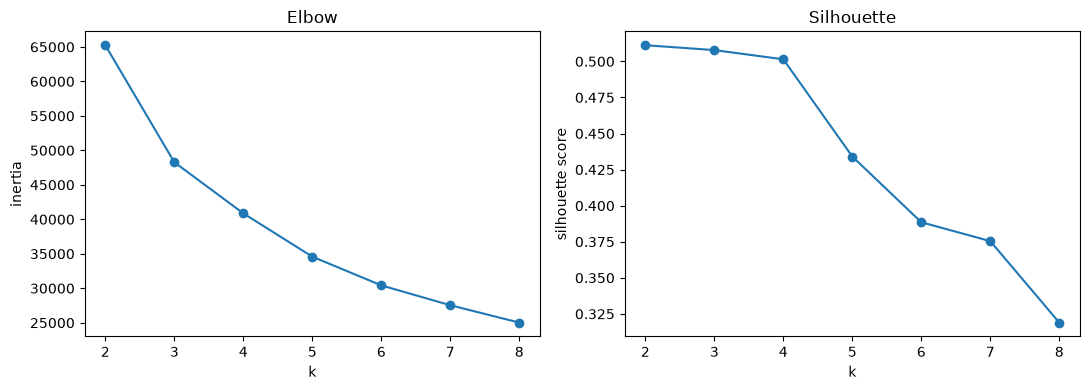


Silhouette 최댓값: k=2 (score=0.5112)


In [2]:
# [C2] 문제 1. Elbow와 Silhouette으로 `k` 후보를 좁힌다
# ⌨️ 문제 1 — k=2~8에서 inertia와 실루엣 재기
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt

# 1. 표준화
X = shoppers[CLUSTER_COLS]
X_scaled = StandardScaler().fit_transform(X)

# 2. k=2~8 반복하며 inertia·silhouette 계산
k_range = range(2, 9)
rows = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_scaled)
    sil = silhouette_score(X_scaled, km.labels_, sample_size=5000, random_state=RANDOM_STATE)
    rows.append({"k": k, "inertia": km.inertia_, "silhouette": sil})

# 3. 표로 정리
result_table = pd.DataFrame(rows)
print(result_table.to_string(index=False))

# 4. 두 지표 각각 선 그래프
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(result_table["k"], result_table["inertia"], marker="o")
axes[0].set_xlabel("k"); axes[0].set_ylabel("inertia"); axes[0].set_title("Elbow")

axes[1].plot(result_table["k"], result_table["silhouette"], marker="o")
axes[1].set_xlabel("k"); axes[1].set_ylabel("silhouette score"); axes[1].set_title("Silhouette")

plt.tight_layout()
plt.show()

best_k = int(result_table.loc[result_table["silhouette"].idxmax(), "k"])
best_sil = result_table["silhouette"].max()
print(f"\nSilhouette 최댓값: k={best_k} (score={best_sil:.4f})")

<details>
<summary>(클릭) 💡 힌트</summary>

- `X_scaled = StandardScaler().fit_transform(shoppers[CLUSTER_COLS])`
- `KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)` — `n_init`을 주지 않으면 초기값 운에 흔들립니다.
- inertia는 학습된 객체의 `.inertia_` 속성입니다.
- 실루엣은 `silhouette_score(X_scaled, km.labels_, sample_size=5000, random_state=RANDOM_STATE)`.
- 두 지표는 크기가 전혀 다르므로 **그래프를 따로** 그리는 게 좋습니다 — `plt.subplots(1, 2, ...)`.

</details>

> 🎯 **[C2] 확인하기**  
> 이 고정 5,000개 표본에서 Silhouette 최댓값은 `k=2`입니다. `k=3`은 0.5078, `k=4`는 0.5015로 차이가 작고 `k=5`부터 더 크게 낮아집니다. 이 결과만으로 0.0097의 차이가 안정적이라고 단정할 수는 없습니다. 다른 표본·시드에서 순위가 유지되는지 확인해야 합니다.  
> 다음 문제에서는 **운영상 비교 가치가 있는 후보 `k=4`를 잠정 선택**해 프로파일을 살펴봅니다. 이는 `k=4`가 통계적 정답이라는 뜻이 아닙니다. 군집 크기·해석 가능성·안정성을 확인한 뒤 채택 여부를 다시 판단합니다.

# 문제 2. k=4로 나누고, 프로파일과 2D 그림으로 확인한다

군집 번호 자체는 아무 의미가 없습니다. 의미는 **각 군집의 특성을 비교**해서 우리가 부여합니다.

```
[문제 2]
1) k=4로 KMeans를 학습시켜 군집 라벨을 얻습니다.
2) 군집별 프로파일 표를 만듭니다.
   → 7개 피처의 평균 + 각 군집의 규모(세션 수) + 구매율
   (구매율은 나눈 '뒤에' 보는 것이므로 규율 위반이 아닙니다)
3) PCA로 2차원으로 줄여 군집을 색으로 구분해 그립니다.
   설명 분산비도 함께 출력합니다.
```

> 🤔 **예상하기**  
> 군집화에 `Revenue`를 넣지 않았습니다. 그런데도 군집별 **구매율**이 크게 갈릴까요? 갈린다면, 그것은 무엇을 뜻할까요?

▶️ **코드 실행하기 · 코드 셀 3 [C3]**

         Administrative  Informational  ProductRelated  \
cluster                                                  
0                 1.777          0.247          22.697   
1                 0.047          0.015           2.879   
2                 7.269          2.540         111.160   
3                 2.599          0.398          29.753   

         ProductRelated_Duration  BounceRates  ExitRates  PageValues  \
cluster                                                                
0                        830.974        0.010      0.033       2.199   
1                         53.412        0.168      0.182       0.000   
2                       4366.436        0.006      0.020       6.498   
3                       1142.265        0.003      0.014      68.935   

         session_count  purchase_rate  
cluster                                
0                 9233          0.109  
1                 1033          0.006  
2                 1441          0.276  
3                 

C:\Users\seoyeon\AppData\Local\Temp\ipykernel_215208\3014738078.py:35: UserWarning: Glyph 44400 (\N{HANGUL SYLLABLE GUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\seoyeon\AppData\Local\Temp\ipykernel_215208\3014738078.py:35: UserWarning: Glyph 51665 (\N{HANGUL SYLLABLE JIB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\seoyeon\.conda\envs\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44400 (\N{HANGUL SYLLABLE GUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\seoyeon\.conda\envs\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51665 (\N{HANGUL SYLLABLE JIB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


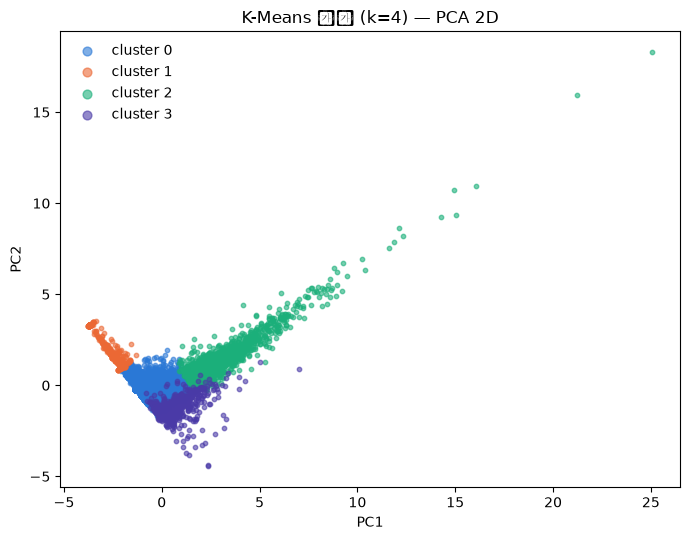

In [3]:
# [C3] 문제 2. k=4로 나누고, 프로파일과 2D 그림으로 확인한다
# ⌨️ 문제 2 — 군집화 → 프로파일 표 → PCA 2D 시각화
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. k=4 군집화 (X_scaled 재사용)
km4 = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE).fit(X_scaled)

# 2. 라벨 붙이고 프로파일 표 만들기
shoppers_c = shoppers.copy()
shoppers_c["cluster"] = km4.labels_

profile = shoppers_c.groupby("cluster")[CLUSTER_COLS].mean()
profile["session_count"] = shoppers_c.groupby("cluster").size()
profile["purchase_rate"] = shoppers_c.groupby("cluster")["Revenue"].mean()

print(profile.round(3))

# 3. PCA 2D 시각화
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print("\n설명 분산비:", pca.explained_variance_ratio_, "합:", pca.explained_variance_ratio_.sum())

colors = ["#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"]  # 군집 4개, 서로 잘 구별되는 색
fig, ax = plt.subplots(figsize=(7, 5.5))
for c in range(4):
    mask = km4.labels_ == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=10, alpha=0.6, color=colors[c], label=f"cluster {c}")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("K-Means 군집 (k=4) — PCA 2D")
ax.legend(frameon=False, markerscale=2)
plt.tight_layout()
plt.show()

In [4]:
scaled_df = pd.DataFrame(X_scaled, columns=CLUSTER_COLS)
scaled_df["cluster"] = km4.labels_
scaled_profile = scaled_df.groupby("cluster").mean()

print(scaled_profile.round(3))

         Administrative  Informational  ProductRelated  \
cluster                                                  
0                -0.162         -0.202          -0.203   
1                -0.683         -0.384          -0.649   
2                 1.491          1.603           1.786   
3                 0.085         -0.083          -0.044   

         ProductRelated_Duration  BounceRates  ExitRates  PageValues  
cluster                                                               
0                         -0.190       -0.259     -0.204      -0.199  
1                         -0.596        3.006      2.853      -0.317  
2                          1.657       -0.324     -0.482       0.033  
3                         -0.027       -0.401     -0.589       3.395  


<details>
<summary>(클릭) 💡 힌트</summary>

- 라벨은 `KMeans(...).fit_predict(X_scaled)`로 한 번에 얻습니다.
- 프로파일은 `df.groupby("cluster")[CLUSTER_COLS].mean()`입니다.
- 규모는 `df["cluster"].value_counts().sort_index()`, 구매율은 `df.groupby("cluster")["Revenue"].mean()`.
- PCA는 **표준화된 배열**에 적용합니다: `PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_scaled)`.
- 산점도에서 군집을 색으로 나누려면 `c=labels`를 주면 됩니다. 점이 많으니 `s=5, alpha=0.4` 정도가 보기 좋습니다.

</details>

> 🎯 **[C3] 확인하기**  
> **구매율이 0.58%에서 79.29%까지, 약 137배로 갈립니다.** `Revenue`를 한 번도 보여주지 않았는데 말입니다.
>
> 군집 입력에 `Revenue`를 넣지 않았어도 행동 피처와 구매 결과가 연관되어 있어 구매율이 크게 갈립니다. 특히 `PageValues`는 거래 완료와 관련된 지표이므로 이 차이는 완전히 뜻밖의 발견이 아닙니다. 실시간 개입에 사용하려면 피처 확정 시점을 먼저 확인합니다.
>
> PCA 2D는 전체 분산의 **63.15%** 만 담습니다. 그림에서 겹쳐 보이는 점들이 실제로는 다른 군집일 수 있으니, **그림은 확인용이고 판단은 프로파일 표로** 해야 합니다.

# 문제 3. 세그먼트 카드 — 번호를 세션 패턴으로 옮긴다

`"군집 3은 Silhouette 0.50"`만으로는 업무 결정을 내릴 수 없습니다. 군집별 수치를 근거로 **세션 행동 유형과 검증할 액션 가설**을 작성합니다.

```
[문제 3]
1) 네 군집에 세션 패턴 이름을 붙입니다.
2) 각 세그먼트에 다음을 기록합니다.
   - 규모(세션 수와 전체 대비 비율)
   - 근거 지표 2~3개
   - 행동 해석 한 문장
   - 액션 가설 1개와 확인할 지표
   - 우선순위 근거
3) 세션 단위·PageValues 시점·인과 해석의 한계를 기록합니다.
```

> 🤔 **예상하기**  
> 구매율이 79.29%인 군집 3과 10.95%인 군집 0 가운데 어느 쪽을 먼저 개선해야 하는지는 구매율만으로 정할 수 있을까요? 필요한 추가 근거를 생각합니다.

▶️ **코드 실행하기 · 코드 셀 4 [C4]**

In [5]:
# [C4] 문제 3. 세그먼트 카드 — 번호를 세션 패턴으로 옮긴다
# ⌨️ 문제 3 — 세션 패턴 카드용 요약 표 만들기

segment_cards = {
    0: dict(name="일반 탐색형", size="9,233건 (74.9%)", purchase_rate=0.109,
            evidence="ProductRelated 22.7 · Duration 831s · PageValues 2.2, 이탈률 낮음",
            interpretation="목적성 약한 일반 탐색, 전환은 평균 이하",
            action="개인화 추천으로 다음 단계 유도",
            check="추천 노출 후 PageValues·구매율 변화",
            priority="규모 큼(75%) → 임팩트 크지만 신호 약해 확신도 낮음"),
    1: dict(name="즉시 이탈형", size="1,033건 (8.4%)", purchase_rate=0.006,
            evidence="ProductRelated 2.9 · Duration 53s · Bounce/Exit 최고",
            interpretation="관심 형성 전 즉시 이탈",
            action="랜딩 콘텐츠·유입 채널 점검",
            check="채널별 비중, 5초 내 이탈률",
            priority="구매율 0.6% → 전환 개선 대상 아님, 유입 품질 진단용"),
    2: dict(name="고관여 탐색형", size="1,441건 (11.7%)", purchase_rate=0.276,
            evidence="ProductRelated 111.2 · Duration 4,366s · 이탈률 최저",
            interpretation="꼼꼼히 비교하는 신중 구매형 / 구매 직전 단계",
            action="위시리스트·비교함·재방문 리마인드 제공",
            check="도입 전후 구매율, 재방문율",
            priority="구매율 평균 이상 + 규모 있음 → 투자 대비 효율 좋음"),
    3: dict(name="구매 임박/완료형", size="623건 (5.1%)", purchase_rate=0.793,
            evidence="PageValues 68.9(압도적) · 이탈률 최저",
            interpretation="PageValues가 구매완료와 순환적으로 얽혀 원인 아닌 결과일 가능성",
            action="결제 단계 UX 점검만 — 인과 해석은 하지 않음",
            check="군집 내 미구매(20.7%) 세션의 이탈 지점",
            priority="규모 작고 인과 신뢰도 최저 → 우선순위 낮음"),
}

for c, card in segment_cards.items():
    print(f"[군집 {c}] {card['name']} · {card['size']} · 구매율 {card['purchase_rate']*100:.1f}%")
    print(f"  근거   : {card['evidence']}")
    print(f"  해석   : {card['interpretation']}")
    print(f"  액션   : {card['action']}")
    print(f"  확인지표: {card['check']}")
    print(f"  우선순위: {card['priority']}\n")

limitations = [
    "세션 단위(고객 식별자 없음) → '세션 행동 유형'으로만 해석",
    "PageValues는 거래완료 연관 지표 → 군집3 해석 시 순환 논리 주의",
    "군집 간 차이는 상관관계 → 액션 가설은 A/B 테스트 등으로 별도 검증 필요",
]
print("한계:")
for l in limitations:
    print(f"- {l}")

[군집 0] 일반 탐색형 · 9,233건 (74.9%) · 구매율 10.9%
  근거   : ProductRelated 22.7 · Duration 831s · PageValues 2.2, 이탈률 낮음
  해석   : 목적성 약한 일반 탐색, 전환은 평균 이하
  액션   : 개인화 추천으로 다음 단계 유도
  확인지표: 추천 노출 후 PageValues·구매율 변화
  우선순위: 규모 큼(75%) → 임팩트 크지만 신호 약해 확신도 낮음

[군집 1] 즉시 이탈형 · 1,033건 (8.4%) · 구매율 0.6%
  근거   : ProductRelated 2.9 · Duration 53s · Bounce/Exit 최고
  해석   : 관심 형성 전 즉시 이탈
  액션   : 랜딩 콘텐츠·유입 채널 점검
  확인지표: 채널별 비중, 5초 내 이탈률
  우선순위: 구매율 0.6% → 전환 개선 대상 아님, 유입 품질 진단용

[군집 2] 고관여 탐색형 · 1,441건 (11.7%) · 구매율 27.6%
  근거   : ProductRelated 111.2 · Duration 4,366s · 이탈률 최저
  해석   : 꼼꼼히 비교하는 신중 구매형 / 구매 직전 단계
  액션   : 위시리스트·비교함·재방문 리마인드 제공
  확인지표: 도입 전후 구매율, 재방문율
  우선순위: 구매율 평균 이상 + 규모 있음 → 투자 대비 효율 좋음

[군집 3] 구매 임박/완료형 · 623건 (5.1%) · 구매율 79.3%
  근거   : PageValues 68.9(압도적) · 이탈률 최저
  해석   : PageValues가 구매완료와 순환적으로 얽혀 원인 아닌 결과일 가능성
  액션   : 결제 단계 UX 점검만 — 인과 해석은 하지 않음
  확인지표: 군집 내 미구매(20.7%) 세션의 이탈 지점
  우선순위: 규모 작고 인과 신뢰도 최저 → 우선순위 낮음

한계:
- 세션 단위(고객 식별자 없음) → '세션 행동 유형'으로만 해석
- PageValues는 거래완료 연관

| 근거 | 군집 0 (구매율 10.9%) | 군집 3 (구매율 79.3%) |
|---|---|---|
| 세션 수 | 9,233건 | 623건 |
| 현재 구매 건수(추정) | ~1,006건 | ~494건 |
| 개선 여지(헤드룸) | 최대 +5~10%p → +462~900건 | 최대 +20.7%p → +129건 |
| 인과성 | 뚜렷한 지표 없음 → 원인 파악 필요, 개입 여지 있음 | `PageValues`가 구매와 순환적으로 얽힘 → 개입 레버 불명확 |
| 표본 신뢰도 | 표본 큼 → 추정치 안정적 | 표본 작음 → 79.3%의 신뢰구간 넓음 |
| 결론 | 임팩트 크고 확신도 낮은 우선 개선 대상 | 개선 대상 아님 (이미 구매 임박/완료), 다른 목적(이탈 방지 등)으로 접근 |

<details>
<summary>(클릭) 💡 힌트</summary>

- 카드 작성은 손으로 하지만, **근거 숫자는 코드로** 뽑아 두면 옮겨 적기 쉽습니다.
- 전체 대비 비율은 `규모 / len(shoppers)`입니다.
- 세그먼트별 "기대 구매 건수"도 유용합니다 — `규모 × 구매율`. 우선순위를 정할 때 구매율만 보는 것과 다른 답이 나옵니다.
- 표를 그대로 CSV로 저장해 두면 카드와 함께 제출할 수 있습니다.

</details>

> 🎯 **[C4] 확인하기**  
> 구매율·규모·관측 구매 건수는 서로 다른 우선순위를 만들지만 어느 값도 개입 효과를 직접 알려 주지 않습니다. 높은 구매율 집단에 쿠폰이 불필요한지, 긴 탐색 집단에 비교 도구가 효과적인지는 무작위 실험이나 준실험으로 확인해야 합니다.  
> 세그먼트 카드는 **관찰된 패턴 → 액션 가설 → 확인 지표**를 연결하는 문서입니다. 사람을 단정하는 페르소나가 아니라 검증 가능한 업무 가설로 작성합니다.

# 문제 4. 군집 중심거리 피처를 예측 모델에 재투입한다

`KMeans.transform()`이 만드는 각 중심까지의 거리를 예측 피처로 사용할 수 있습니다. `KMeans`도 중심을 학습하므로 교차 검증의 학습 조각에서만 `fit`해야 합니다.

```
[문제 4]
1) 세 방식을 같은 층화 5겹 CV로 평가합니다. 모델은 순서 5의 RandomForest(`min_samples_leaf=5`)입니다.
   ① 군집 파생 피처 없음
   ② `Pipeline` 안에서 표준화 → KMeans(4) 중심거리 생성(정상)
   ③ 전체 데이터로 미리 fit한 표준화·KMeans 중심거리 사용(누수)
2) F1과 AP 차이를 계산합니다.
3) 군집 파생 피처 채택 여부를 정하고 근거를 기록합니다.
4) 효과가 관찰되지 않았다면 데이터와 모델 구조로 설명합니다.
```

> 🤔 **예상하기**  
> 군집화에 쓴 7개 열은 이미 RandomForest 입력에 들어 있습니다. 같은 열을 요약한 중심거리 피처가 새 예측 정보를 제공할지 예상합니다. 누수 버전의 점수가 반드시 더 높아야 하는지도 함께 생각합니다.

▶️ **코드 실행하기 · 코드 셀 5 [C5]**

In [6]:
# [C5] 문제 4. 군집 중심거리 피처를 예측 모델에 재투입한다
# ⌨️ 문제 4 — 없음 / Pipeline 안 중심거리 / 전체-fit 중심거리 3방향 비교
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd

# 0. 커스텀 변환기 — 표준화 + KMeans를 한 단위로 묶어 폴드 안전성 보장
class KMeansDistance(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=4, random_state=RANDOM_STATE):
        self.n_clusters = n_clusters
        self.random_state = random_state
    def fit(self, X, y=None):
        self.scaler_ = StandardScaler().fit(X)
        self.km_ = KMeans(n_clusters=self.n_clusters, n_init=10,
                           random_state=self.random_state).fit(self.scaler_.transform(X))
        return self
    def transform(self, X):
        return self.km_.transform(self.scaler_.transform(X))

FEATURES = NUM_COLS + CAT_COLS
X_full = shoppers[FEATURES]
y = shoppers["Revenue"].astype(int)

def make_rf():
    return RandomForestClassifier(min_samples_leaf=5, random_state=RANDOM_STATE)

# ① 군집 파생 피처 없음
prep_base = ColumnTransformer([
    ("num", "passthrough", NUM_COLS),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
])
pipe1 = Pipeline([("prep", prep_base), ("clf", make_rf())])

# ② Pipeline 안 KMeans — 폴드의 학습 조각에서만 표준화·KMeans fit
prep_inside = ColumnTransformer([
    ("num", "passthrough", NUM_COLS),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
    ("cluster_dist", KMeansDistance(n_clusters=4, random_state=RANDOM_STATE), CLUSTER_COLS),
])
pipe2 = Pipeline([("prep", prep_inside), ("clf", make_rf())])

# ③ 전체 데이터로 미리 fit한 중심거리 (누수)
scaler_all = StandardScaler().fit(shoppers[CLUSTER_COLS])
km_all = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE).fit(
    scaler_all.transform(shoppers[CLUSTER_COLS]))
dist_all = km_all.transform(scaler_all.transform(shoppers[CLUSTER_COLS]))

X_leak = X_full.copy()
dist_cols = [f"dist_{i}" for i in range(dist_all.shape[1])]
X_leak[dist_cols] = dist_all

prep_leak = ColumnTransformer([
    ("num", "passthrough", NUM_COLS + dist_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
])
pipe3 = Pipeline([("prep", prep_leak), ("clf", make_rf())])

# 세 파이프라인을 같은 CV로 평가
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["f1", "average_precision"]

results = {}
for name, pipe, X_in in [("① 없음", pipe1, X_full),
                          ("② Pipeline 안 (정상)", pipe2, X_full),
                          ("③ 전체-fit (누수)", pipe3, X_leak)]:
    s = cross_validate(pipe, X_in, y, cv=cv, scoring=scoring)
    results[name] = {"F1": s["test_f1"].mean(), "AP": s["test_average_precision"].mean()}

result_table = pd.DataFrame(results).T
result_table["F1_diff_vs_①"] = result_table["F1"] - result_table.loc["① 없음", "F1"]
result_table["AP_diff_vs_①"] = result_table["AP"] - result_table.loc["① 없음", "AP"]

print(result_table.round(4))

                       F1      AP  F1_diff_vs_①  AP_diff_vs_①
① 없음               0.6173  0.7417        0.0000        0.0000
② Pipeline 안 (정상)  0.6328  0.7418        0.0154        0.0001
③ 전체-fit (누수)      0.6256  0.7401        0.0083       -0.0016


### 채택 여부
②를 채택하는 게 맞습니다. 이유는 두 가지입니다. 
- 첫째, 세 방식 중 성능이 가장 좋습니다(F1 최고, AP 동률 최고). 
- 둘째, 이번엔 우연히 ③이 성능을 부풀리지 않았지만, 그건 "이 데이터셋·이 표본 크기에서 우연히" 그런 거고, 구조적으로 ③은 여전히 방법론적 오류(미래/테스트 정보가 전처리에 섞여 들어감)를 안고 있습니다. 
- 실무에서 새로운 세션이 들어올 때마다 전체 데이터를 다시 모아 KMeans를 재학습해야 한다는 것도 비현실적이고. 그러니 "이번엔 누수가 해를 안 끼쳤다"는 결과와 "누수 구조 자체를 채택해도 된다"는 건 다른 이야기입니다. 

### 효과가 크지 않은 이유
F1은 소폭(+0.016) 늘고 AP는 거의 그대로인 이유는 모델 구조 차이 때문입니다.
- 로지스틱회귀(지난 예제, F1 +0.037): 선형 모델이라 "중심거리"라는 비선형 정보를 명시적으로 줘야 큰 도움이 됨
- RandomForest(이번): 트리 분기로 비선형 경계를 이미 스스로 근사 → 거리 피처가 주는 추가 정보가 적음
- F1만 소폭 상승: 임계값 0.5 근처 경계 케이스 일부만 옳은 쪽으로 이동
- AP 불변: 전체 확률 순위는 원본 피처로도 이미 비슷하게 매겨짐

<details>
<summary>(클릭) 💡 힌트</summary>

- `KMeans`는 **변환기로도 쓸 수 있습니다.** `ColumnTransformer`의 한 갈래에 `Pipeline([("sc", StandardScaler()), ("km", KMeans(...))])`를 넣으면, 각 군집 중심까지의 거리 `k`개가 피처로 나옵니다.
- 그 갈래에 넘길 열 목록이 `CLUSTER_COLS`입니다.
- ③은 일부러 잘못 만드는 방식입니다. 전체 데이터에 `StandardScaler.fit`과 `KMeans.fit`을 호출한 뒤, 정상 버전과 동일한 중심거리 4개를 만듭니다.
- 세 구성 모두 모델·나머지 전처리·군집 표현을 같게 둡니다. 정상은 중심거리인데 누수 버전은 군집 번호라면 공정한 비교가 아닙니다.
- 순서 5의 최종 구성은 수치 10개 + `has_page_value` + 범주 7개(`min_frequency=10`), 모델은 `min_samples_leaf=5`입니다.

</details>

> 🎯 **[C5] 확인하기**  
> 이 데이터와 RandomForest에서는 군집 중심거리 피처의 추가 이득을 확인하지 못했습니다. 군집 입력 7개가 이미 모델에 포함되어 있어 중심거리는 중복된 재표현일 수 있습니다.  
> 그렇다고 세그먼테이션 전체가 실패한 것은 아닙니다. 문제 3의 세션 유형은 사이트 개선 가설을 만드는 탐색 산출물입니다. 다만 액션 효과는 후속 실험으로 검증해야 합니다.  
> **군집화의 가치는 예측 성능과 업무 탐색에서 따로 평가**하며, 유리한 지표만 골라 결론 내리지 않습니다.

# 문제 5. 모델 카드 v6 완성 — 오늘의 제출물

v6에는 **정답 없는 결과를 보고하는 법**이 들어갑니다. 성능 숫자만으로 정당화할 수 없는 산출물이라, `k` 선택 근거와 한계 서술이 카드의 절반을 차지합니다.

```
[문제 5]
1) 세그먼트 프로파일 표를 CSV로 저장합니다 — segment_profile_v6.csv
2) 문제 3의 세그먼트 카드 4장을 아래 셀 아래에 마크다운으로 붙입니다.
3) 아래 모델 카드 v6 템플릿의 빈칸을 채웁니다.
```

▶️ **코드 실행하기 · 코드 셀 6 [C6]**

In [7]:
# [C6] 문제 5. 모델 카드 v6 완성 — 오늘의 제출물
# ⌨️ 문제 5 — 세그먼트 프로파일을 파일로 남기기

profile.to_csv("segment_profile_v6.csv", encoding="utf-8-sig")

**모델 카드 v6 템플릿** — 빈칸을 채워 이 셀에 완성합니다.

```markdown
## 모델 카드 v6 — 방문 세션 세그먼테이션

- 데이터: UCI Online Shoppers 12,330세션 · CC BY 4.0
- 군집 입력: 행동 피처 7개 (Administrative, Informational, ProductRelated, ProductRelated_Duration, BounceRates, ExitRates, PageValues)
  - `Revenue` 미사용 확인: 예 (군집 입력에서 제외, 결과 검증에만 사용)
  - `PageValues` 사용 목적·확정 시점 한계: 완료된 세션을 회고적으로 탐색하는 목적이라 포함했으나, 거래 완료와 연관되어 계산되는 값이라 실시간 예측·개입에 쓰려면 요청 시점에 값이 확정되어 있는지 별도 확인 필요
- 스케일링: `StandardScaler` — 7개 피처의 단위·범위가 서로 달라(페이지 수 vs 초 단위 체류시간 vs 비율) 표준화 없이는 거리 계산이 특정 변수에 치우치기 때문
- `k` 후보: Silhouette k=2 { 0.511234 } / k=3 { 0.507850 } / k=4 { 0.501458 } / k=5 { 0.434067 }
  - 채택 `k=4`와 근거: {  실루엣 최댓값은 k=2(0.5112)지만 k=2~4 구간은 0.50~0.51로 거의 평탄해 통계적 손실이 미미(k=2→4, -0.01)함. k=5부터 0.434로 급락해 그 이상은 과분할로 판단. k=2는 세션을 두 덩어리로만 나눠 업무 활용도가 낮은 반면, k=4는 즉시이탈·일반탐색·고관여탐색·구매임박처럼 실무적으로 구분 가능한 세션 유형을 얻을 수 있어 채택 }
- 시각화: PCA 2D 설명 분산비 0.4116(PC1) + 0.2199(PC2) = 0.6315
  - 그림만으로 판단하지 않은 이유: 전체 분산의 63%만 담고 있어 정보 손실이 크고, 산점도에서 군집 0·1·3이 원점 근처에서 서로 겹쳐 보여 시각적 분리만으로는 실제 구분력을 과대/과소평가할 수 있음
- 세그먼트 카드: 세션 패턴 4장 (일반 탐색형 / 즉시 이탈형 / 고관여 탐색형 / 구매 임박·완료형)
  - 규모·구매율 범위: 12,330세션 / 0.6%~79.3%
  - 액션 가설과 확인 지표: 일반 탐색형→개인화 추천(PageValues·구매율 변화 확인), 즉시 이탈형→유입 채널 점검(채널별 비중·즉시이탈률 확인), 고관여 탐색형→위시리스트·재방문 리마인드(구매율·재방문율 확인), 구매 임박형→결제 UX 점검만(인과 해석은 보류)
- 군집 중심거리 피처 검증
  - ① 없음 AP 0.7418 / ② Pipeline 안 0.7418 / ③ 전체-fit 누수 0.7401
  - 채택 여부: ② 채택 — 근거: F1 최고(+0.016)·AP 동률 최고이면서 절차상 누수가 없음
  - 누수 점검: 스케일러와 KMeans가 Pipeline 안에 있는가 예 (채택안 ② 기준)
- 한계: 세션 단위(고객 식별자 없음) / `PageValues` 확정 시점 불확실 / 군집 간 차이는 상관관계이며 인과 효과 미검증
- AI 사용 내역: 클러스터링·PCA·파이프라인 기반 누수 검증 코드 작성을 요청 → 과도하게 길었던 초안(불필요한 안전장치·시각화 요소)을 지적받아 간결화 → 교차검증 결과표(F1·AP)를 직접 확인하고 baseline과 비교해 효과·누수 여부를 검증
```

**제출:** 노트북·`segment_profile_v6.csv`·세그먼트 카드 4장을 개인 공개 저장소의 main 브랜치에 커밋·푸시하고 저장소·커밋 링크를 제출합니다.

**스스로 점검하는 기준**

| 축 | 기준 |
| --- | --- |
| 번역 품질 | 고객을 단정하지 않고 세션 패턴과 액션 가설로 옮겼는가 |
| 근거성 | 각 해석에 프로파일 수치가 붙어 있는가 |
| 누수 점검 | 동일한 중심거리 표현으로 비교하고 `fit` 범위를 확인했는가 |
| 정직성 | PageValues 시점·세션 단위·인과 미검증·이득 없음의 한계를 적었는가 |

> 🚀 **더 나아가기**  
> `PageValues`를 군집 입력에서 제외했을 때 프로파일과 구매율 차이가 얼마나 달라지는지 비교합니다. 이 실험은 강한 거래 관련 피처가 세그먼트 해석을 얼마나 지배했는지 점검합니다.

오늘은 방문 세션을 네 가지 행동 패턴으로 탐색하고, 중심거리 피처가 예측 성능을 높이지 않은 결과도 그대로 기록했습니다.

군집은 사람의 본질을 찾아내는 답이 아니라, 선택한 피처·거리·알고리즘이 만든 탐색 결과입니다. 프로파일을 업무 가설로 번역하고 시점·누수·인과 한계를 함께 적을 때 분석이 신뢰를 얻습니다.

오늘도 한 걸음, 수고하셨습니다! 🎉  
어제의 나보다 데이터를 다루는 손이 한 뼘 더 능숙해졌습니다. 다음 시간에 또 만나요.

---

<sub>© 2026 모두의연구소(MODULABS). All rights reserved.<br>
기획·제작: 교육퍼실리테이터팀 이진영 (jy.lee@modulabs.co.kr)<br>
본 자료는 생성형 AI를 활용해 제작되었고, 제작자의 검수를 거쳐 완성되었습니다.<br>
무단 복제 및 배포를 금합니다.</sub>